In [88]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time

import geopandas as gpd

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

ERROR 1: PROJ: proj_create_from_database: Open of /home/lhasbini/.conda/envs/dev/share/proj failed


In [48]:
# all_reports = pd.read_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv')
file_path = DATA_IN_JSONS +'filtered_report_types_nat_hazards_summary-header.json'#'nathaz_ifrc_reports_info_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
all_reports = pd.DataFrame(ifrc_reports_processed)
all_reports = all_reports.rename({"location" : "country"}, axis=1)
# all_reports = all_reports.rename({"disasterTypeReclassified" : "hazardType"}, axis=1)

In [52]:
expanded_df = all_reports.explode('hazards_found')
expanded_df = expanded_df.reset_index(drop=True)
expanded_df = expanded_df.rename({"hazards_found" : "hazardType"}, axis=1)

all_reports = expanded_df

In [25]:
#Load 
world = gpd.read_file(DATA_PATH+"ne_50m_admin_0_countries/"+'ne_50m_admin_0_countries.shp')
admin1 = gpd.read_file(DATA_PATH+"ne_10m_admin_1_states_provinces/"+'ne_10m_admin_1_states_provinces.shp')
rivers = gpd.read_file(DATA_PATH+"ne_10m_rivers_lake_centerlines/"+'ne_10m_rivers_lake_centerlines.shp')
cities = gpd.read_file(DATA_PATH+"ne_10m_populated_places/"+'ne_10m_populated_places.shp')

## Map nb of events + types of events 

In [6]:
all_reports_grp = all_reports.groupby('appealCode').agg(country = ("country", "first")).reset_index()

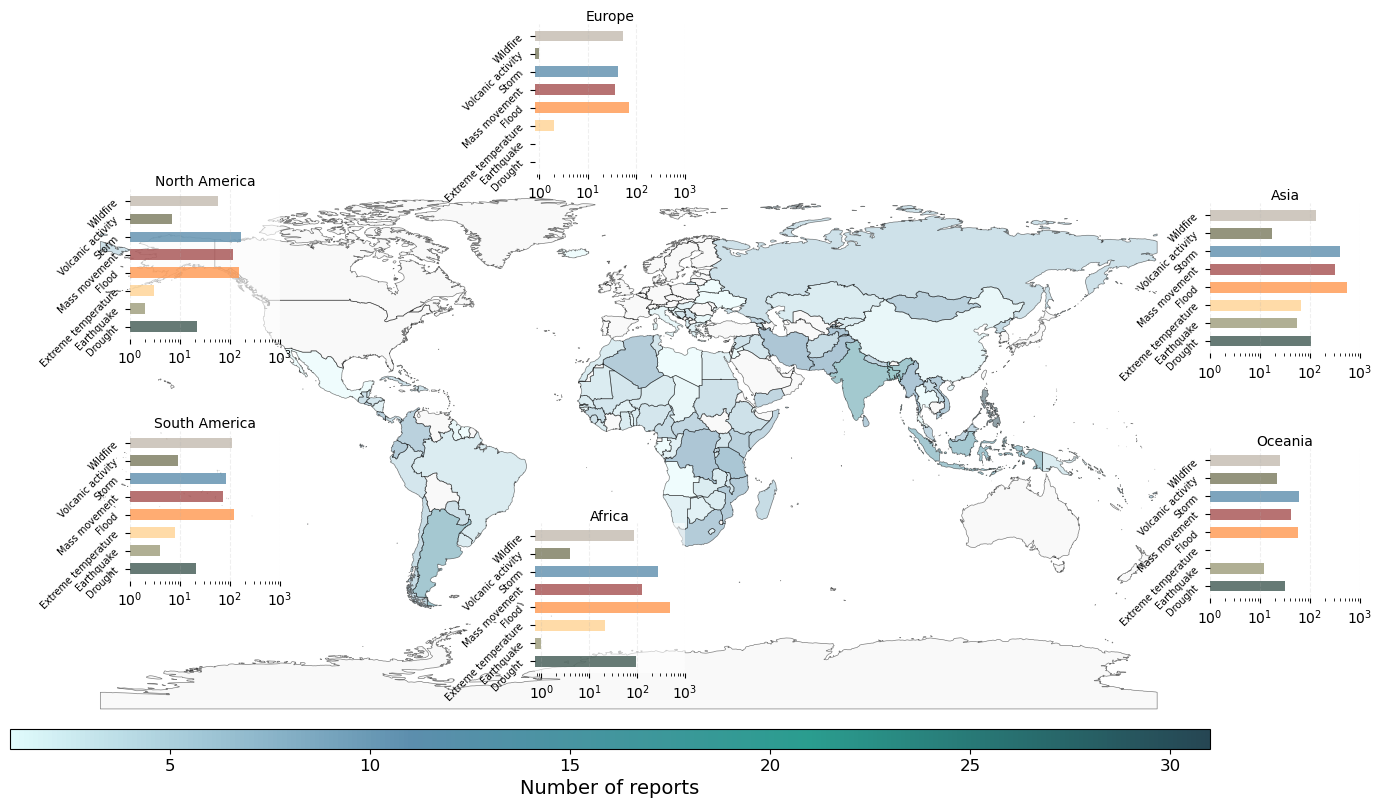

In [84]:
import pycountry
import geopandas as gpd
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap  

# Step 1: Map country names to ISO codes and count unique appeal codes per country
country_appeal_count = defaultdict(set)

for appeal_code, country_name in zip(all_reports_grp['appealCode'], all_reports_grp['country']):
    try:
        country = pycountry.countries.get(name=country_name)
        if country:
            iso_code = country.alpha_3  # ISO 3166-1 Alpha-3 code
            country_appeal_count[iso_code].add(appeal_code)  # Add unique appealCode
    except KeyError:
        continue
country_appeal_count = {iso: len(codes) for iso, codes in country_appeal_count.items()}

# Step 2: Create a DataFrame from the counts
df = pd.DataFrame(list(country_appeal_count.items()), columns=["iso_code", "appeal_count"])

world_2 = world.merge(df, how="left", left_on="ISO_A3", right_on="iso_code")

# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world_2.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)  # Semi-transparent boundaries

# Plot the map with color based on the appeal_count column
sequential_cmap = LinearSegmentedColormap.from_list(
    "cool_sequential", 
    ["#E0FBFC", "#5C8EAD", "#2A9D8F", "#264653"],  # Light teal → Dark teal
    N=256
)
world_plot = world_2.plot(column="appeal_count", 
                        ax=ax, 
                        legend=False, 
                        cmap=sequential_cmap, 
                        missing_kwds={
                            "color": "whitesmoke",
                            "label": "No data"
                        }, alpha=0.5)

# Reduce the size of the colorbar
sm = plt.cm.ScalarMappable(cmap=sequential_cmap, norm=plt.Normalize(vmin=world_2['appeal_count'].min(), vmax=world_2['appeal_count'].max()))
sm._A = []  # Dummy array for ScalarMappable
cbar_ax = fig.add_axes([0.1, 0.2, 0.8, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Number of reports", fontsize=14)

# Set plot title and labels
# ax.set_title("Appeal frequency per country", fontsize=16)
ax.set_axis_off()  # Hide axis


# --- Step 4: Group hazard types by continent and plot histogram ---
# Get continent for each country
def get_continent(iso_code):
    try:
        return world_2[world_2['ISO_A3'] == iso_code]['CONTINENT'].values[0]
    except IndexError:
        return None

# Map ISO codes to continents
all_reports['continent'] = all_reports['country'].apply(
    lambda x: get_continent(pycountry.countries.get(name=x).alpha_3) if pycountry.countries.get(name=x) else None
)

# Filter out rows without continent
valid_continents = all_reports.dropna(subset=['continent'])

# Group by continent and hazard type
hazard_counts = valid_continents.groupby(['continent', 'hazardType']).size().unstack(fill_value=0)

# --- Step 5: Plot mini horizontal bars on continents ---
# Get centroids of dissolved continents
continent_offsets = {
    'Africa': (0, -0.23),
    'Asia': (0.15, -0.05),
    'Europe': (-0.15, -0.02),
    'Oceania' : (0.08, 0.02), 
    'North America' : (-0.05, -0.15), 
    'South America' : (-0.05, -0.02)
}

continent_shapes = world_2.dissolve(by='CONTINENT')#.to_crs('ESRI:54030')
# continent_centroids = continent_shapes.geometry.centroid
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid

# Reproject centroids back to original CRS (WGS84) to overlay on the map
continent_centroids = continent_centroids_proj.to_crs(world_2.crs)

# Plot only for continents with data
continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
for continent in continents_plot:#hazard_counts.index:
    if continent not in continent_centroids.index:
        continue
        
    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue
    
    try:
        # Create a small axis for the bar plot
        norm_x = (centroid.x + 180) / 360
        norm_y = (centroid.y + 90) / 180 
        x_offset, y_offset = continent_offsets.get(continent, (0, 0))

        if continent in ['North America', 'South America']:
            ax_bar = fig.add_axes([0.18, norm_y - 0.03 + y_offset, 0.1, 0.15])
        elif continent in ['Asia', 'Oceania']:
            ax_bar = fig.add_axes([0.9, norm_y - 0.03 + y_offset, 0.1, 0.15])
        else : 
            ax_bar = fig.add_axes([0.45, norm_y - 0.03 + y_offset, 0.1, 0.15]) 

        data = hazard_counts.loc[continent]
        # print("Before plot")
        # if not data.empty:
        # Filter out zero values for cleaner visualization
        ax_bar.set_facecolor('white')
        ax_bar.patch.set_alpha(0.6)
        
        values = data.values
        labels = data.index.str.wrap(10)
        
        # color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
        #               '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
        color_list = [
            '#405952',  # Dark slate
            '#9C9B7A',  # Sage
            '#FFD393',  # Sand
            '#FF974F',  # Terracotta
            '#A54F4F',  # Rust
            '#5C8EAD',  # Steel blue
            '#7A7A5D',  # Olive
            '#C4BBAF',  # Warm gray
        ]

        # color_list = [
        #     '#264653',  # Charcoal teal
        #     '#2A9D8F',  # Persian green
        #     '#E9C46A',  # Maize
        #     '#F4A261',  # Sandy brown
        #     '#E76F51',  # Burnt sienna
        #     '#6B4D7B',  # Royal lavender
        #     '#9B5DE5',  # Lighter purple
        #     '#EF476F',  # Fiery rose
        # ]
        
        colors = color_list[:len(values)]  # Take as many colors as needed
        ax_bar.barh(
            y=range(len(values)), 
            width=values, 
            color=colors,  # Different color for each bar
            alpha=0.8, 
            height=0.6
        )
        
        ax_bar.set_title(continent[:15], fontsize=10, pad=2)
        ax_bar.title.set_position([0.5, 1.1])
        
        # ax_bar.set_xticks(np.arange(10, 50, 10))  # 5 tick marks evenly spaced
        # ax_bar.tick_params(axis='x', labelsize=6)
        ax_bar.set_xscale('log')
        ax_bar.set_xticks([10**x for x in range(4)])
        
        ax_bar.set_yticks(range(len(labels)))  # Consistent y-ticks for all plots
        ax_bar.set_yticklabels(data.index, fontsize=7, rotation=45)
        for spine in ax_bar.spines.values():
            spine.set_visible(False)
        ax_bar.grid(axis='x', alpha=0.2, linestyle='--')      
    except Exception as e:
        print(f"Error plotting {continent}: {e}")
        continue  # Skip if there's any error creating the mini plot
# plt.tight_layout()
plt.show()
fig.savefig(DATA_FIGURE+"hazard_map.svg", format="svg", bbox_inches="tight", dpi=300, transparent=True)

In [86]:
labels

Index(['Drought', 'Earthquake', 'Extreme te\nmperature', 'Flood',
       'Mass\nmovement', 'Storm', 'Volcanic\nactivity', 'Wildfire'],
      dtype='object', name='hazardType')

In [ ]:
color_dict = {'Wildfire' : '#405952', 
              'Volcanic activity' : '#9C9B7A',
              'Storm' : '#FFD393', 
              'Mass movement' : '#FF974F', 
              'Flood' : '#A54F4F',  
              'Extreme temperature' : '#5C8EAD',  
              'Earthquake' : '#7A7A5D',  
              'Drought' : '#C4BBAF'
}

# Map case study

In [67]:
dict_color = {"Flood" : "blue", "Storm" : "purple", "Mass movement" : "brown", "Wave action": "pink", "Extreme temperature" : "red"}
dict_marker = {
    "Flood": "o",         # Circle
    "Earthquake": "s",    # Square
    "Mass movement": "^", # Triangle
    "Storm": "*",         # Diamond
    "Drought": "p",       # Pentagon
    "Extreme temperature": "v",      # Star
    "Wave action": "h"
}

In [68]:
def centeroidnp(arr):
    length = arr.shape[0]
    sum_x = np.sum(arr[:, 0])
    sum_y = np.sum(arr[:, 1])
    return sum_x/length, sum_y/length

In [80]:
appealCode_test = "MDRBD022"#"MDRSD034"#"MDRBD022"#"MDRKE058"
report_cs = all_reports.loc[all_reports.appealCode == appealCode_test]

In [81]:
grouping_columns = ["hazardType", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 

#Output from chat
report_cs[grouping_columns] = report_cs[grouping_columns].fillna('missing')
report_cs_event = report_cs.groupby(grouping_columns)

/tmp/ipykernel_32298/266169816.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  report_cs[grouping_columns] = report_cs[grouping_columns].fillna('missing')


In [126]:
admin1.head(5)

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
0,Admin-1 scale rank,2,AUS-2651,2651,AU-WA,None,AU,6,Western Australia,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((113.13181 -25.95199, 113.14823..."
1,Admin-1 scale rank,2,AUS-2650,2650,AU-NT,None,AU,6,Northern Territory,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((129.00196 -25.99901, 129.00196..."
2,Admin-1 scale rank,2,AUS-2655,2655,AU-SA,None,AU,3,South Australia,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((129.00196 -31.69266, 129.00196..."
3,Admin-1 scale rank,2,AUS-2657,2657,AU-QLD,None,AU,5,Queensland,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((138.00196 -25.99901, 138.00174..."
4,Admin-1 scale rank,2,AUS-2660,2660,AU-TAS,None,AU,5,Tasmania,None,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((147.31246 -43.28038, 147.34238..."


In [129]:
admin1_10 = gpd.read_file(DATA_PATH+"ne_10m_admin_1_states_provinces/"+'ne_10m_admin_1_states_provinces.shp')

In [132]:
admin1_10.admin.nunique()

253

In [133]:
admin1.admin.nunique()

9

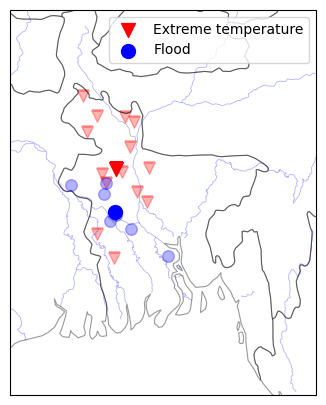

In [147]:
import geopandas as gpd
def add_jitter(coords, scale=0.05):
    return coords + np.random.uniform(-scale, scale, size=coords.shape)

f, axes = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(13, 5))
world.boundary.plot(ax=axes, color="black", linewidth=0.8, alpha=0.4)

# bd_admin1 = admin1[admin1['admin'].isin(list(report_cs.country.unique()))]
# bd_admin1.boundary.plot(ax=axes, color="black", linewidth=0.5, alpha=0.4)

rivers_in_region = rivers.cx[85:95, 15:30]
rivers_in_region.plot(ax=axes, color='blue', linewidth=0.6, alpha=0.3)

# # Filter cities within our region of interest
# cities_in_region = cities.cx[85:95, 15:30]

# # Plot cities and add labels
# for x, y, name in zip(cities_in_region.geometry.x, cities_in_region.geometry.y, cities_in_region['NAME']):
#     axes.plot(x, y, 'o', color='black', markersize=3, alpha=0.5)
#     # Add text with white stroke for better visibility
#     text = ax.text(x, y, name, fontsize=8, ha='left', va='bottom')
#     text.set_path_effects([withStroke(linewidth=2, foreground='white')])

#For result with chat
keys_chat = report_cs_event.groups.keys()
for i in keys_chat : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    chat_event_loop = report_cs_event.get_group(i) 
    hazard = chat_event_loop["hazardType"].iloc[0]
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    chat_event_loop = report_cs_event.get_group(i) 
    coordinates_chat = np.column_stack((chat_event_loop["longitude"], chat_event_loop["latitude"]))
    centroid_chat = centeroidnp(coordinates_chat)
    
    coordinates_gpd = gpd.GeoDataFrame(chat_event_loop, geometry=gpd.points_from_xy(chat_event_loop.longitude, chat_event_loop.latitude))
    x_values = coordinates_gpd.geometry.x#add_jitter(coordinates_gpd.geometry.x)
    y_values = coordinates_gpd.geometry.y#add_jitter(coordinates_gpd.geometry.y)

    axes.scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3
    )
    
    axes.scatter(
            centroid_chat[0], centroid_chat[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label=hazard
        )
# axes.set_title("Chat")

# Set the focus on Uganda
# for ax in axes : 
axes.set_xlim([87, 93.5])  # Longitude limits
axes.set_ylim([20.5, 28])  # Latitude limits
axes.legend(fontsize=10)
# plt.suptitle("Report - "+appealCode_test)
plt.show()